In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


In [29]:
df=pd.read_csv('data/Students.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [30]:
X=df.drop(columns=['math score'],axis=1)
y=df['math score']

In [31]:
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

In [32]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transfrom=StandardScaler()
categorical_transfrom=OneHotEncoder(drop='first')

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",categorical_transfrom,cat_features),
        ('StandardScaler',numeric_transfrom,num_features)
    ], remainder='passthrough'
)

In [33]:
X=preprocessor.fit_transform(X)
X

array([[ 0.        ,  1.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((800, 14), (200, 14))

In [35]:
def evaluate_model(true,pred):
    r2=r2_score(true,pred)
    mae=mean_absolute_error(true,pred)
    mse=mean_squared_error(true,pred)
    rmse=np.sqrt(mean_squared_error(true,pred))
    return r2,mae,mse,rmse

In [38]:
models={
    "KNeighborsRegressor":KNeighborsRegressor(),
    "LinearRegression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "AdaBoostRegressor":AdaBoostRegressor(),
    "SVR":SVR(),
    "CatBoostRegressor":CatBoostRegressor(),
    "XGBRegressor":XGBRegressor()    
}
model_list=[]
r2_list=[]

for i in range (len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    
    y_train_r2,y_train_mse,y_train_mae,y_train_rmse=evaluate_model(y_train,y_train_pred)
    y_test_r2,y_test_mse,y_test_mae,y_test_rmse=evaluate_model(y_test,y_test_pred)
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    r2_list.append(y_test_r2)
    
    print('-------------------------------')
    
    print("Train performance")
    print('Root mean square error:{:.4f}'.format(y_train_rmse))
    print('mean absolute error:{:.4f}'.format(y_train_mae))
    print('r2 score :{:.4f}'.format(y_train_r2))
    
    print('\n')
    
    print("Test performance:")
    print('Root mean square error:{:.4f}'.format(y_test_rmse))
    print('mean absolute error:{:.4f}'.format(y_test_mae))
    print('r2 score :{:.4f}'.format(y_test_r2))


KNeighborsRegressor
-------------------------------
Train performance
Root mean square error:5.5780
mean absolute error:31.1144
r2 score :0.8620


Test performance:
Root mean square error:7.4075
mean absolute error:54.8710
r2 score :0.7745
LinearRegression
-------------------------------
Train performance
Root mean square error:5.3231
mean absolute error:28.3349
r2 score :0.8743


Test performance:
Root mean square error:5.3940
mean absolute error:29.0952
r2 score :0.8804
Ridge
-------------------------------
Train performance
Root mean square error:5.3235
mean absolute error:28.3397
r2 score :0.8743


Test performance:
Root mean square error:5.3936
mean absolute error:29.0908
r2 score :0.8805
Lasso
-------------------------------
Train performance
Root mean square error:6.5938
mean absolute error:43.4784
r2 score :0.8071


Test performance:
Root mean square error:6.5197
mean absolute error:42.5064
r2 score :0.8253
DecisionTreeRegressor
-------------------------------
Train performance

In [40]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['model name','r2 score']).sort_values(by=['r2 score'],ascending=False)

,model name,r2 score
2,Ridge,0.880451
1,LinearRegression,0.880433
5,RandomForestRegressor,0.852516
8,CatBoostRegressor,0.849801
6,AdaBoostRegressor,0.845989
3,Lasso,0.825320
9,XGBRegressor,0.825046
0,KNeighborsRegressor,0.774507
4,DecisionTreeRegressor,0.741430
7,SVR,0.713014


In [41]:
lin_model=LinearRegression(fit_intercept=True)
lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)
print("Accuracy of the model is : %.2f", score)

Accuracy of the model is : %.2f 0.8804332983749564


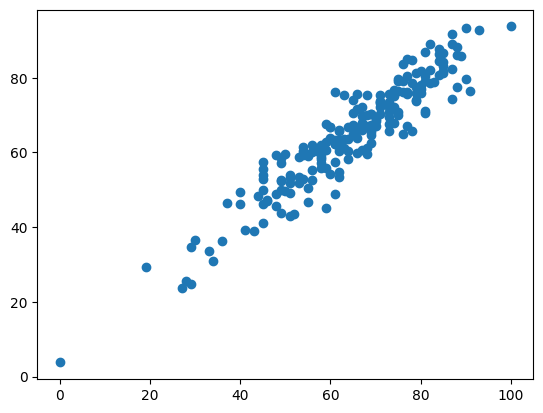

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actaul values")
plt.ylabel('predict values')

<Axes: xlabel='math score'>

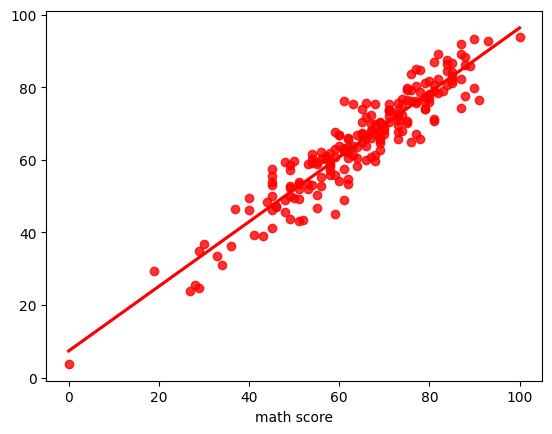

In [44]:
sns.regplot(x=y_test,y=y_pred,ci=None,color="red")

In [46]:
z={
    "Actual values":y_test,
    "predict values": y_pred,
    "difference": y_test-y_pred
}
pd.DataFrame(z)

,Actual values,predict values,difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
